# RQ1 Answer: Modality-Dependent Temporal Genre Evolution

**RQ1:** How much do music genres change over time across acoustic, visual, and lyrical feature modalities?

This notebook is the inspection and interpretation notebook for RQ1. The calculation-heavy steps are expected to be done by:

```bash
python src/04_answer_RQ1_calculate_drift.py
```

The notebook loads the saved drift outputs, creates the main RQ1 plots and tables, and provides a compact structure for answering the research question.

This version additionally starts with a dataset-level drift baseline and a top-drifting-genres overview per modality.

## Load Libraries And Paths

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from helper_functions import PROCESSED_DIR
except ImportError:
    PROJECT_ROOT = Path.cwd()

    PROJECT_ROOT = PROJECT_ROOT.parent.parent.parent

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CENTROID_DIR = PROCESSED_DIR / "03_ortools_centroids"
DRIFT_DIR = PROCESSED_DIR / "04_ortools_centroid_drift"
PLOTS_DIR = PROJECT_ROOT / "plots" / "RQ1_answer"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Centroid directory:", CENTROID_DIR)
print("Drift directory:", DRIFT_DIR)
print("Plots directory:", PLOTS_DIR)

Centroid directory: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/03_ortools_centroids
Drift directory: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/04_ortools_centroid_drift
Plots directory: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer


## Load RQ1 Drift Outputs

In [23]:
drift_wpz = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_wpz.parquet"
)

drift_wpz_neighbors = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_wpz_neighbors.parquet"
)

drift_raw = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_raw.parquet"
)

drift_raw_neighbors = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_raw_neighbors.parquet"
)

modality_summary = pd.read_csv(
    DRIFT_DIR / "rq1_modality_drift_summary_wpz_neighbors.csv"
)

genre_drift_summary = pd.read_csv(
    DRIFT_DIR / "rq1_genre_drift_summary_wpz_neighbors.csv"
)

landscape_drift = pd.read_parquet(
    DRIFT_DIR / "rq1_selected_genre_landscape_drift_wpz_neighbors.parquet"
)

raw_vs_wpz_summary = pd.read_csv(
    DRIFT_DIR / "rq1_raw_vs_wpz_drift_summary.csv"
)

modalities = sorted(drift_wpz_neighbors["modality"].unique())

print("Modalities:", modalities)
print("WPZ neighboring transitions:", drift_wpz_neighbors.shape)
print("Raw neighboring transitions:", drift_raw_neighbors.shape)

Modalities: ['essentia', 'lyrics_tf_idf', 'mfcc', 'musicnn', 'vgg19', 'word2vec']
WPZ neighboring transitions: (12670, 12)
Raw neighboring transitions: (12670, 12)


## Dataset-Level Drift Baseline

This section compares genre-level centroid drift with the selected-genre landscape drift. The landscape baseline is calculated by comparing the centroid of all selected-genre tracks in one window with the centroid of all selected-genre tracks in the next window. It is used as a reference for interpreting whether genre-level movement is larger than the general movement of the analysed dataset.

In [24]:
# Calculate each genre's drift first, then weight genres equally.
genre_drift_by_window = (
    drift_wpz_neighbors
    .groupby(["modality", "window_start", "genre"], as_index=False)
    .agg(
        genre_mean_cosine_distance=("cosine_distance", "mean"),
        n_genre_transitions=("cosine_distance", "size"),
    )
)

mean_genre_drift_over_time = (
    genre_drift_by_window
    .groupby(["modality", "window_start"], as_index=False)
    .agg(
        mean_genre_cosine_distance=("genre_mean_cosine_distance", "mean"),
        median_genre_cosine_distance=("genre_mean_cosine_distance", "median"),
        n_genres=("genre", "nunique"),
        n_genre_transitions=("n_genre_transitions", "sum"),
    )
)

# The landscape drift table may use a slightly different distance-column name.
landscape_distance_column = "cosine_distance"

if landscape_distance_column not in landscape_drift.columns:
    cosine_distance_candidates = [
        column for column in landscape_drift.columns
        if "cosine" in column and "distance" in column
    ]

    if not cosine_distance_candidates:
        raise KeyError(
            "Could not find a cosine distance column in landscape_drift. "
            f"Available columns: {landscape_drift.columns.tolist()}"
        )

    landscape_distance_column = cosine_distance_candidates[0]

landscape_baseline_over_time = (
    landscape_drift[
        ["modality", "window_start", landscape_distance_column]
    ]
    .rename(
        columns={
            landscape_distance_column: "landscape_cosine_distance",
        }
    )
)

dataset_level_baseline = mean_genre_drift_over_time.merge(
    landscape_baseline_over_time,
    on=["modality", "window_start"],
    how="left",
)

dataset_level_baseline["genre_minus_landscape_cosine_distance"] = (
    dataset_level_baseline["mean_genre_cosine_distance"]
    - dataset_level_baseline["landscape_cosine_distance"]
)

dataset_level_baseline.head()

,modality,window_start,mean_genre_cosine_distance,median_genre_cosine_distance,n_genres,n_genre_transitions,landscape_cosine_distance,genre_minus_landscape_cosine_distance
0,essentia,1955,0.055475,0.045604,6,6,0.002789,0.052686
1,essentia,1956,0.062264,0.064191,6,6,0.001023,0.061240
2,essentia,1957,0.076275,0.068763,6,6,0.004827,0.071449
3,essentia,1958,0.113989,0.125805,6,6,0.008896,0.105094
4,essentia,1959,0.124093,0.107207,9,9,0.001576,0.122517


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_mean_genre_drift_with_track_coverage.png


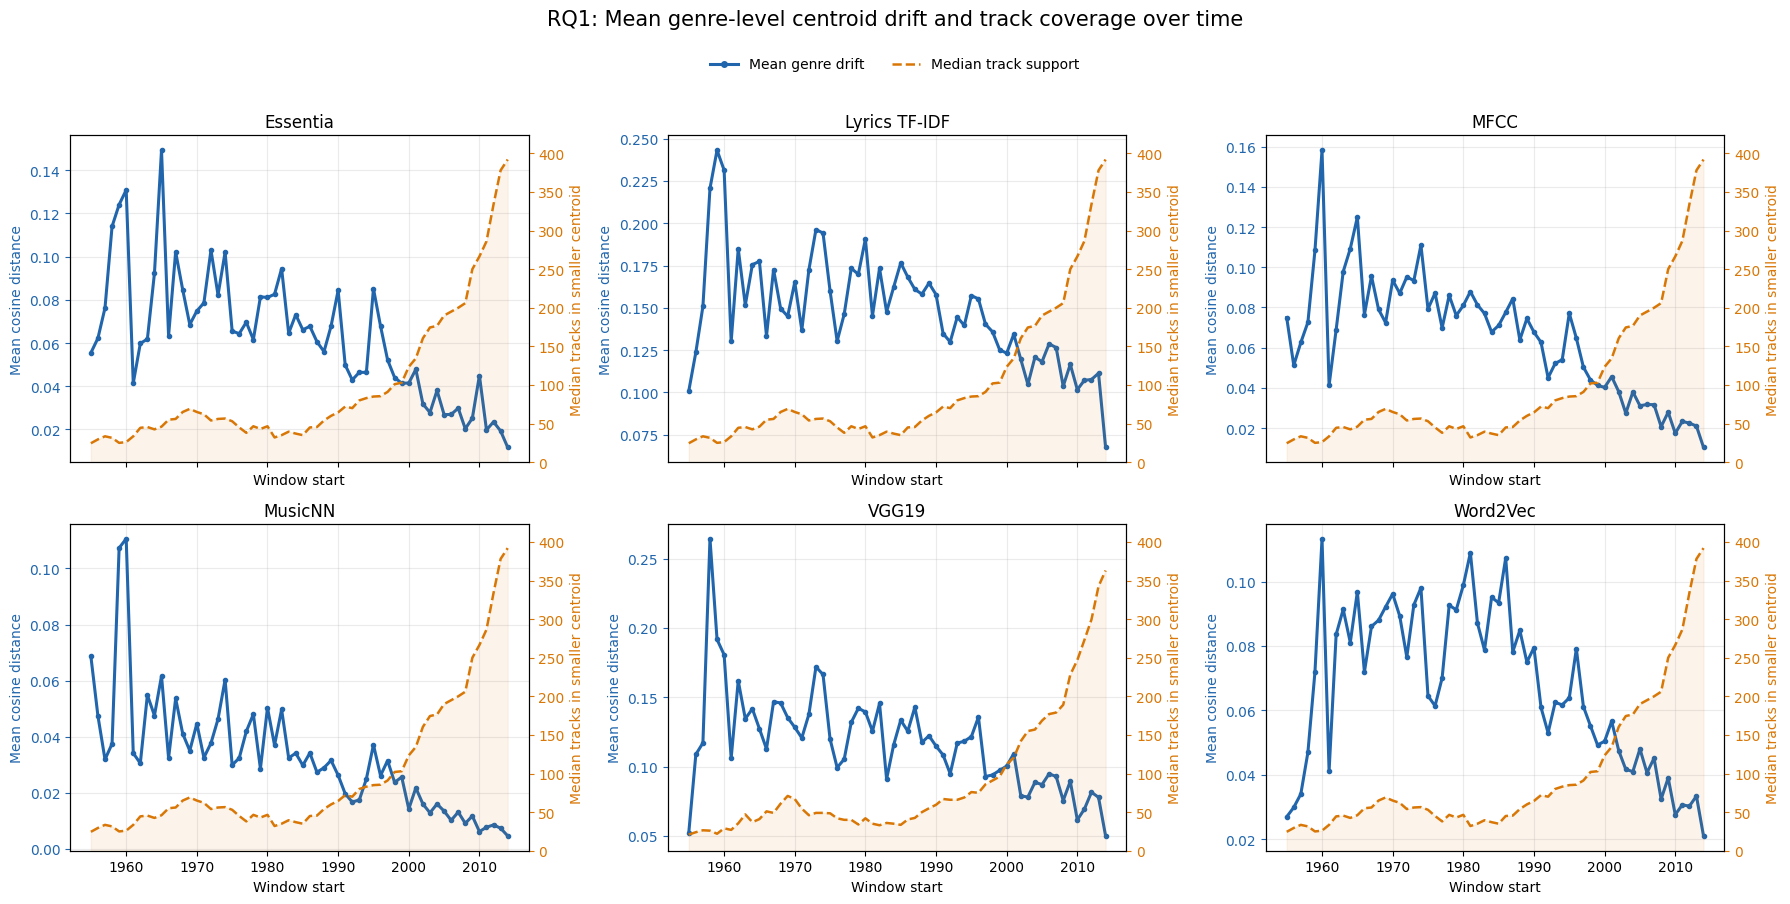

In [36]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

drift_for_plot = drift_wpz_neighbors.copy()

# The smaller centroid determines the effective support of a transition.
drift_for_plot["minimum_track_support"] = drift_for_plot[
    ["n_tracks_t", "n_tracks_t1"]
].min(axis=1)

# Calculate genre-level values first so that every genre is weighted equally.
genre_window_summary = (
    drift_for_plot
    .groupby(
        ["modality", "window_start", "genre"],
        as_index=False,
    )
    .agg(
        genre_mean_cosine_distance=("cosine_distance", "mean"),
        minimum_track_support=("minimum_track_support", "median"),
    )
)

temporal_summary = (
    genre_window_summary
    .groupby(
        ["modality", "window_start"],
        as_index=False,
    )
    .agg(
        mean_genre_cosine_distance=(
            "genre_mean_cosine_distance",
            "mean",
        ),
        median_minimum_track_support=(
            "minimum_track_support",
            "median",
        ),
        n_genres=("genre", "nunique"),
    )
)

modality_labels = {
    "lyrics_tf_idf": "Lyrics TF-IDF",
    "vgg19": "VGG19",
    "word2vec": "Word2Vec",
    "mfcc": "MFCC",
    "essentia": "Essentia",
    "musicnn": "MusicNN",
}

drift_color = "#2166ac"
coverage_color = "#d97706"

# Use the same coverage scale in all panels.
coverage_limit = (
    temporal_summary["median_minimum_track_support"].max() * 1.08
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    sharex=True,
)

axes = axes.ravel()

for ax, modality in zip(axes, modalities):
    modality_data = (
        temporal_summary[
            temporal_summary["modality"] == modality
        ]
        .sort_values("window_start")
    )

    # Left axis: mean genre-level cosine drift.
    ax.plot(
        modality_data["window_start"],
        modality_data["mean_genre_cosine_distance"],
        color=drift_color,
        linewidth=2.2,
        marker="o",
        markersize=3,
        label="Mean genre drift",
        zorder=3,
    )

    ax.set_title(modality_labels.get(modality, modality))
    ax.set_xlabel("Window start")
    ax.set_ylabel(
        "Mean cosine distance",
        color=drift_color,
    )
    ax.tick_params(axis="y", colors=drift_color)
    ax.grid(alpha=0.25)

    # Right axis: median support of the smaller centroid.
    coverage_ax = ax.twinx()

    coverage_ax.plot(
        modality_data["window_start"],
        modality_data["median_minimum_track_support"],
        color=coverage_color,
        linewidth=1.8,
        linestyle="--",
        label="Median track support",
        zorder=2,
    )

    coverage_ax.fill_between(
        modality_data["window_start"],
        0,
        modality_data["median_minimum_track_support"],
        color=coverage_color,
        alpha=0.08,
        zorder=1,
    )

    coverage_ax.set_ylim(0, coverage_limit)
    coverage_ax.set_ylabel(
        "Median tracks in smaller centroid",
        color=coverage_color,
    )
    coverage_ax.tick_params(axis="y", colors=coverage_color)

for ax in axes[len(modalities):]:
    ax.axis("off")

legend_handles = [
    Line2D(
        [0],
        [0],
        color=drift_color,
        linewidth=2.2,
        marker="o",
        markersize=4,
        label="Mean genre drift",
    ),
    Line2D(
        [0],
        [0],
        color=coverage_color,
        linewidth=1.8,
        linestyle="--",
        label="Median track support",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.96),
)

fig.suptitle(
    "RQ1: Mean genre-level centroid drift and track coverage over time",
    fontsize=15,
    y=1.0,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

output_path = (
    PLOTS_DIR
    / "rq1_mean_genre_drift_with_track_coverage.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

print(output_path)
plt.show()

In [26]:
dataset_level_baseline_summary = (
    dataset_level_baseline
    .groupby("modality", as_index=False)
    .agg(
        mean_genre_cosine_distance=("mean_genre_cosine_distance", "mean"),
        median_genre_cosine_distance=("median_genre_cosine_distance", "median"),
        mean_landscape_cosine_distance=("landscape_cosine_distance", "mean"),
        mean_genre_minus_landscape=("genre_minus_landscape_cosine_distance", "mean"),
        n_windows=("window_start", "nunique"),
        mean_n_genre_transitions=("n_genre_transitions", "mean"),
    )
    .sort_values("mean_genre_cosine_distance", ascending=False)
)

dataset_level_baseline_summary

,modality,mean_genre_cosine_distance,median_genre_cosine_distance,mean_landscape_cosine_distance,mean_genre_minus_landscape,n_windows,mean_n_genre_transitions
1,lyrics_tf_idf,0.148275,0.139068,0.000408,0.147867,60,35.433333
4,vgg19,0.117362,0.090378,0.005010,0.112352,60,34.000000
5,word2vec,0.066769,0.047666,0.000151,0.066618,60,35.433333
2,mfcc,0.065403,0.045316,0.000063,0.065340,60,35.433333
0,essentia,0.063016,0.044026,0.000372,0.062645,60,35.433333
3,musicnn,0.032877,0.013631,0.000030,0.032847,60,35.433333


## Top Drifting Genres Per Modality

This table lists the genres with the highest average neighbouring-window cosine drift for each modality. These genres are useful candidates for closer inspection because their centroid positions change most strongly over time within the selected analysis setup.

In [27]:
top_n = 10

top_drifting_genres_per_modality = (
    genre_drift_summary
    .sort_values(
        ["modality", "mean_cosine_distance"],
        ascending=[True, False],
    )
    .groupby("modality")
    .head(top_n)
    .reset_index(drop=True)
)

columns_to_show = [
    column for column in [
        "modality",
        "genre",
        "mean_cosine_distance",
        "median_cosine_distance",
        "n_transitions",
        "first_window",
        "last_window",
        "mean_tracks_t",
        "mean_tracks_t1",
        "median_tracks_t",
        "median_tracks_t1",
    ]
    if column in top_drifting_genres_per_modality.columns
]

top_drifting_genres_per_modality[columns_to_show]

,modality,genre,mean_cosine_distance,median_cosine_distance,n_transitions,median_tracks_t,median_tracks_t1
0,essentia,brazilian rock,0.115420,0.099050,33,47.0,48.0
1,essentia,glam rock,0.112152,0.099426,34,28.5,28.5
2,essentia,experimental,0.110943,0.086651,51,37.0,38.0
3,essentia,rock,0.110260,0.062423,60,149.0,175.5
4,essentia,progressive rock,0.110050,0.086498,52,145.0,158.0
5,essentia,psychedelic rock,0.103921,0.058718,45,59.0,59.0
6,essentia,soft rock,0.102533,0.077291,48,42.0,42.5
7,essentia,post-punk,0.085763,0.063197,42,154.0,157.5
8,essentia,pop rock,0.079275,0.037550,30,130.0,184.5
9,essentia,new wave,0.075743,0.055173,42,133.0,136.5


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_top10_drifting_genres_per_modality.png


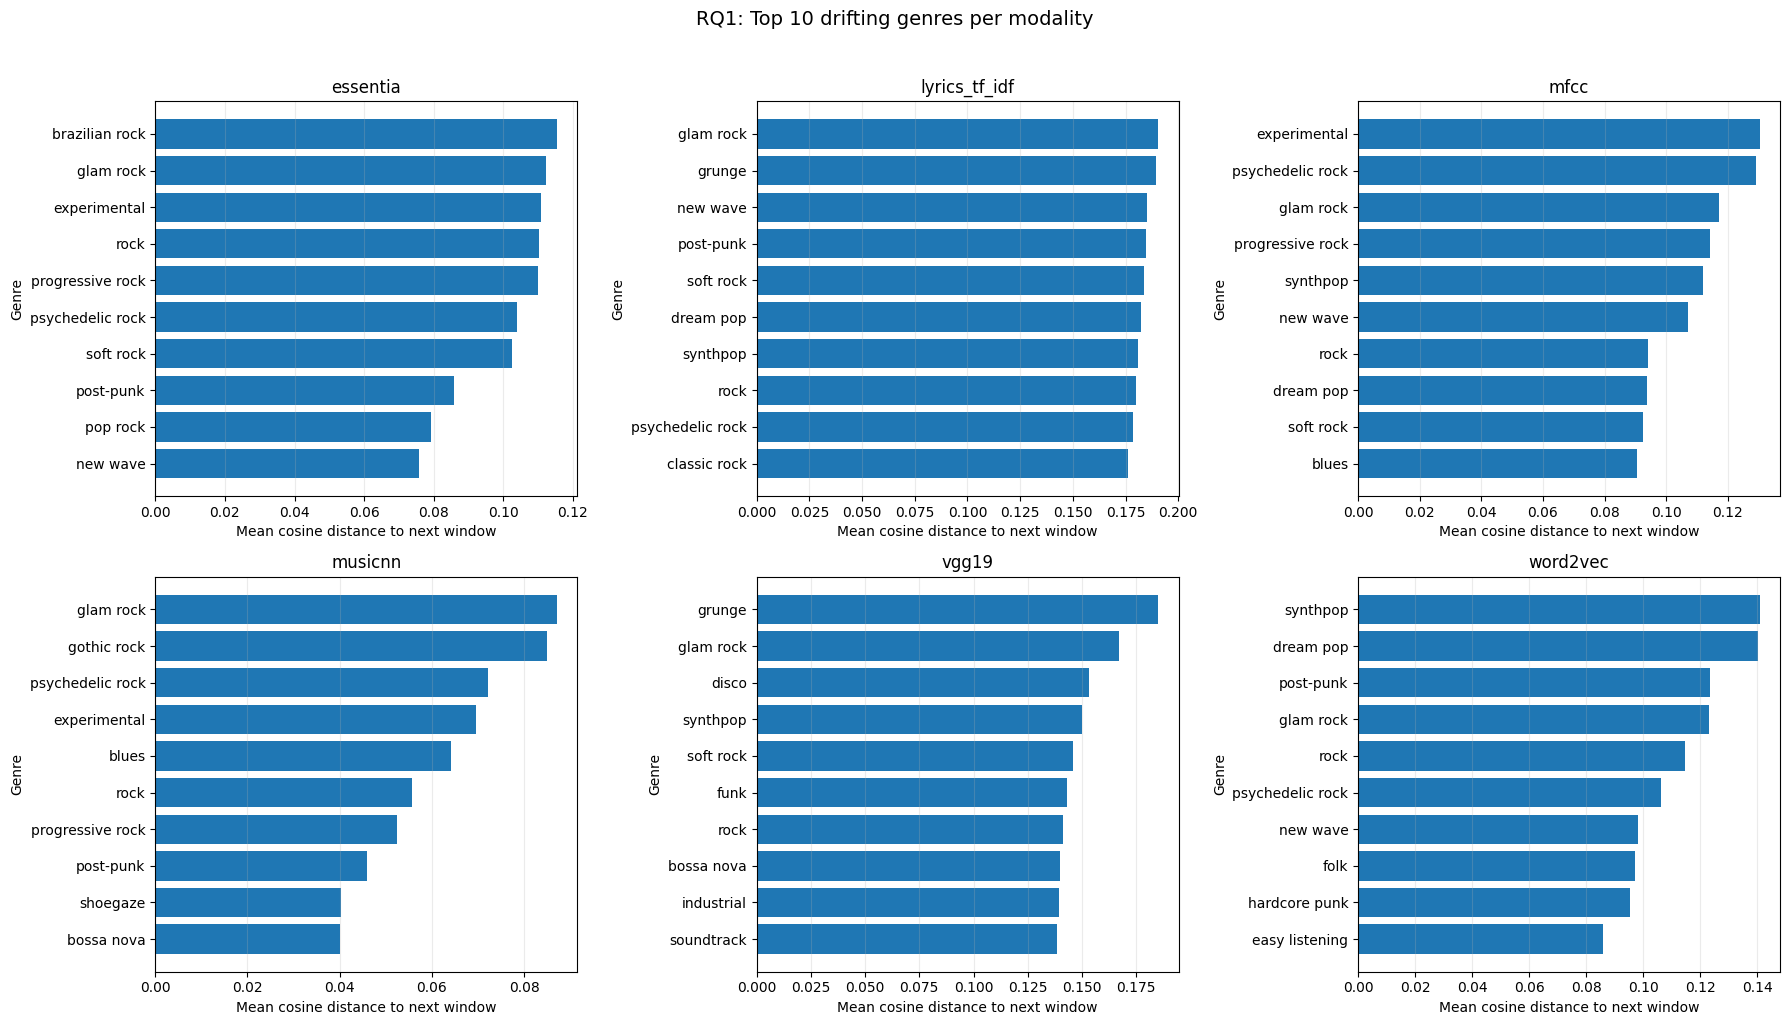

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, modality in zip(axes, modalities):
    modality_top_genres = (
        top_drifting_genres_per_modality[
            top_drifting_genres_per_modality["modality"] == modality
        ]
        .sort_values("mean_cosine_distance", ascending=True)
    )

    ax.barh(
        modality_top_genres["genre"],
        modality_top_genres["mean_cosine_distance"],
    )

    ax.set_title(modality)
    ax.set_xlabel("Mean cosine distance to next window")
    ax.set_ylabel("Genre")
    ax.grid(axis="x", alpha=0.25)

for ax in axes[len(modalities):]:
    ax.axis("off")

fig.suptitle(
    f"RQ1: Top {top_n} drifting genres per modality",
    y=1.02,
    fontsize=14,
)
plt.tight_layout()

output_path = PLOTS_DIR / f"rq1_top{top_n}_drifting_genres_per_modality.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Main RQ1 Summary Table

In [29]:
main_summary = modality_summary[
    [
        "modality",
        "n_transitions",
        "n_genres",
        "mean_cosine_distance",
        "median_cosine_distance",
        "mean_euclidean_distance",
        "median_euclidean_distance",
        "median_tracks_t",
        "median_tracks_t1",
    ]
].copy()

main_summary = main_summary.sort_values(
    "mean_cosine_distance",
    ascending=False,
)

main_summary

,modality,n_transitions,n_genres,mean_cosine_distance,median_cosine_distance,mean_euclidean_distance,median_euclidean_distance,median_tracks_t,median_tracks_t1
0,lyrics_tf_idf,2126,50,0.138956,0.144210,2.337153,2.242259,112.0,116.5
1,vgg19,2040,50,0.106170,0.110277,8.123186,7.972392,99.5,107.5
2,word2vec,2126,50,0.063515,0.062850,1.305929,1.243031,112.0,116.5
3,mfcc,2126,50,0.055637,0.047847,0.773923,0.776803,112.0,116.5
4,essentia,2126,50,0.054254,0.046670,2.338798,2.344472,112.0,116.0
5,musicnn,2126,50,0.025686,0.020989,0.536921,0.496839,112.0,116.5


## Rank Modalities By Average Drift

In [30]:
ranking = main_summary[
    [
        "modality",
        "mean_cosine_distance",
        "median_cosine_distance",
        "mean_euclidean_distance",
    ]
].reset_index(drop=True)

ranking.index = ranking.index + 1
ranking

,modality,mean_cosine_distance,median_cosine_distance,mean_euclidean_distance
1,lyrics_tf_idf,0.138956,0.144210,2.337153
2,vgg19,0.106170,0.110277,8.123186
3,word2vec,0.063515,0.062850,1.305929
4,mfcc,0.055637,0.047847,0.773923
5,essentia,0.054254,0.046670,2.338798
6,musicnn,0.025686,0.020989,0.536921


## Plot Mean Drift By Modality

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_average_drift_by_modality.png


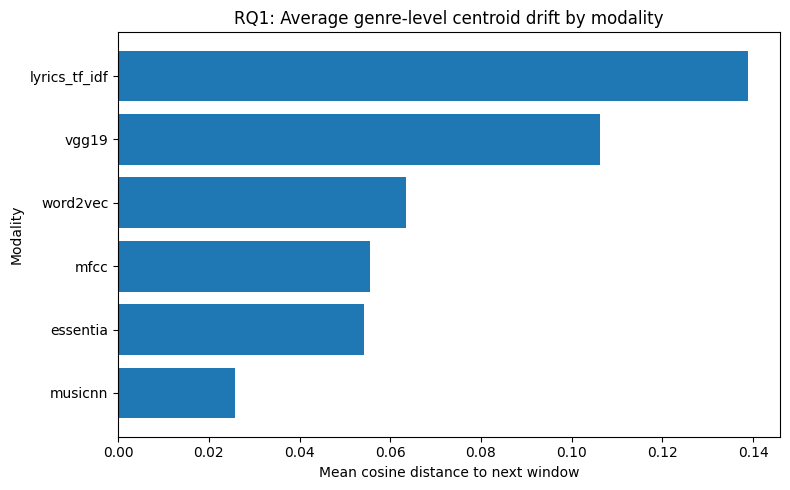

In [31]:
plot_data = main_summary.sort_values("mean_cosine_distance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["modality"],
    plot_data["mean_cosine_distance"],
)
plt.xlabel("Mean cosine distance to next window")
plt.ylabel("Modality")
plt.title("RQ1: Average genre-level centroid drift by modality")
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_average_drift_by_modality.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Plot Drift Distributions Across Modalities

/tmp/ipykernel_1785703/3999717754.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_drift_distribution_by_modality.png


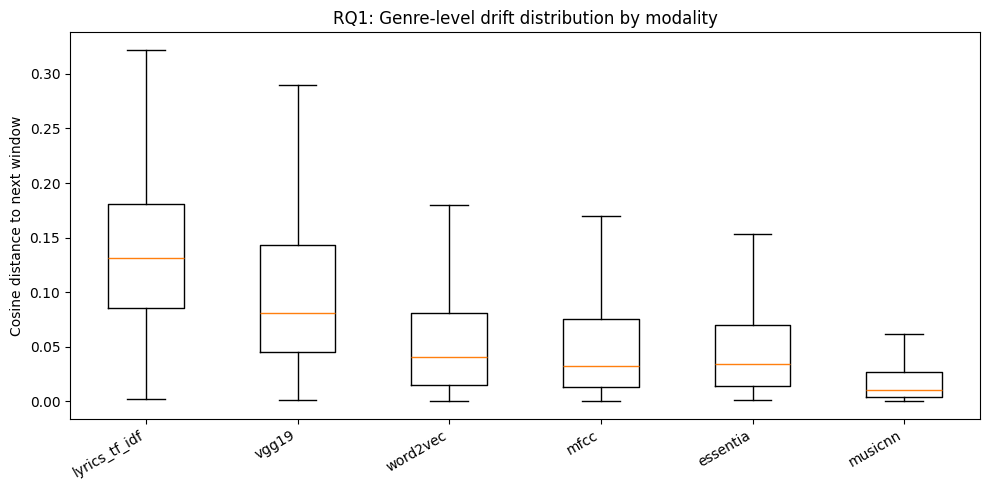

In [32]:
ordered_modalities = main_summary["modality"].tolist()

boxplot_data = [
    drift_wpz_neighbors.loc[
        drift_wpz_neighbors["modality"] == modality,
        "cosine_distance",
    ].dropna()
    for modality in ordered_modalities
]

plt.figure(figsize=(10, 5))
plt.boxplot(
    boxplot_data,
    labels=ordered_modalities,
    showfliers=False,
)
plt.ylabel("Cosine distance to next window")
plt.title("RQ1: Genre-level drift distribution by modality")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_drift_distribution_by_modality.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Plot Drift Over Time

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_mean_drift_over_time.png


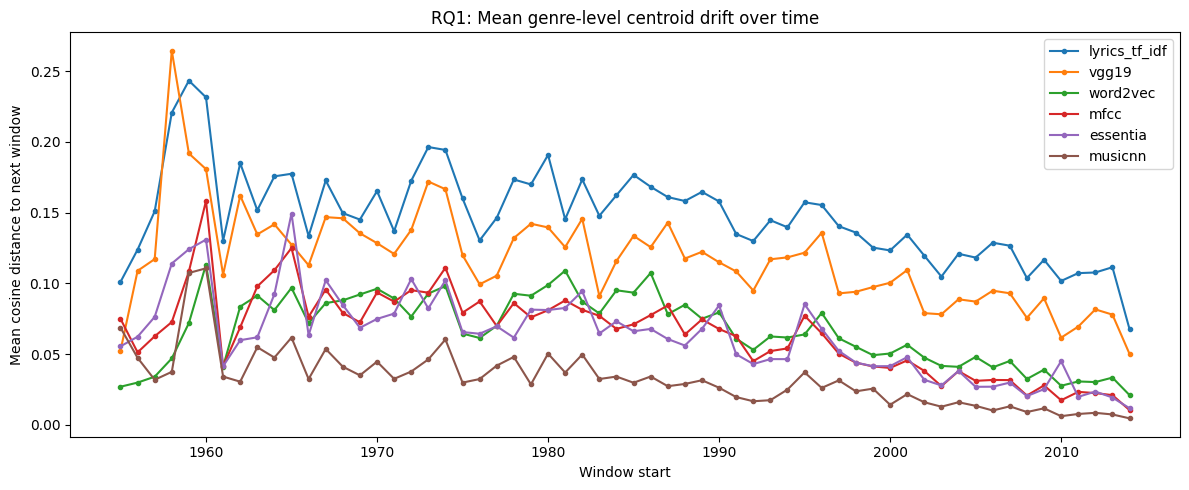

In [33]:
genre_drift_over_time = (
    drift_wpz_neighbors
    .groupby(["modality", "window_start", "genre"], as_index=False)
    .agg(
        genre_mean_cosine_distance=("cosine_distance", "mean"),
        genre_mean_euclidean_distance=("euclidean_distance", "mean"),
    )
)

drift_over_time = (
    genre_drift_over_time
    .groupby(["modality", "window_start"], as_index=False)
    .agg(
        mean_cosine_distance=("genre_mean_cosine_distance", "mean"),
        median_cosine_distance=("genre_mean_cosine_distance", "median"),
        mean_euclidean_distance=("genre_mean_euclidean_distance", "mean"),
        n_genres=("genre", "nunique"),
    )
)

plt.figure(figsize=(12, 5))

for modality in ordered_modalities:
    data = drift_over_time[drift_over_time["modality"] == modality]

    plt.plot(
        data["window_start"],
        data["mean_cosine_distance"],
        marker="o",
        markersize=3,
        label=modality,
    )

plt.xlabel("Window start")
plt.ylabel("Mean cosine distance to next window")
plt.title("RQ1: Mean genre-level centroid drift over time")
plt.legend()
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_mean_drift_over_time.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Compare Genre Drift With Selected-Genre Landscape Baseline

In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

modalities = [
    "essentia",
    "lyrics_tf_idf",
    "mfcc",
    "musicnn",
    "vgg19",
    "word2vec",
]

centroid_tables = []

for modality in modalities:
    path = CENTROID_DIR / f"{modality}_ortools_centroids_wpz_windowed.parquet"

    if not path.exists():
        print(f"Missing: {path}")
        continue

    centroid_table = pd.read_parquet(path).copy()

    # Works whether the column already exists or not.
    centroid_table["modality"] = modality

    centroid_tables.append(centroid_table)

centroids_wpz = pd.concat(
    centroid_tables,
    ignore_index=True,
)

print("Loaded centroid table:")
print(centroids_wpz.shape)
print(centroids_wpz.columns[:15].tolist())

assert "modality" in centroids_wpz.columns
assert "genre" in centroids_wpz.columns
assert "window_start" in centroids_wpz.columns

display(centroids_wpz.head())

Loaded centroid table:
(13109, 10638)
['genre', 'modality', 'window_start', 'window_end', 'window_label', 'n_tracks', 'mean_genre_score', 'median_genre_score', 'lowlevel.average_loudness', 'lowlevel.barkbands.mean_0', 'lowlevel.barkbands.mean_1', 'lowlevel.barkbands.mean_2', 'lowlevel.barkbands.mean_3', 'lowlevel.barkbands.mean_4', 'lowlevel.barkbands.mean_5']


,genre,modality,window_start,window_end,window_label,n_tracks,mean_genre_score,median_genre_score,lowlevel.average_loudness,lowlevel.barkbands.mean_0,...,290,291,292,293,294,295,296,297,298,299
0,blues,essentia,1955,1959,1955_1959,43,2.673721,2.625,-0.374248,-0.055634,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,classic rock,essentia,1955,1959,1955_1959,26,2.687538,1.978,0.578351,-0.060472,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,country,essentia,1955,1959,1955_1959,23,4.520261,5.113,0.469965,-0.055851,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,jazz,essentia,1955,1959,1955_1959,179,2.744832,2.361,-0.127993,-0.058527,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,rock,essentia,1955,1959,1955_1959,22,1.565773,1.223,0.210274,-0.060316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,modality,window_start,mean_genre_cosine_distance,n_genres,landscape_cosine_distance
0,essentia,1955,0.055475,6,0.263846
1,essentia,1956,0.062264,6,0.044240
2,essentia,1957,0.076275,6,0.202437
3,essentia,1958,0.113989,6,0.425351
4,essentia,1959,0.124093,9,0.189625


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_genre_drift_vs_weighted_landscape_baseline.png


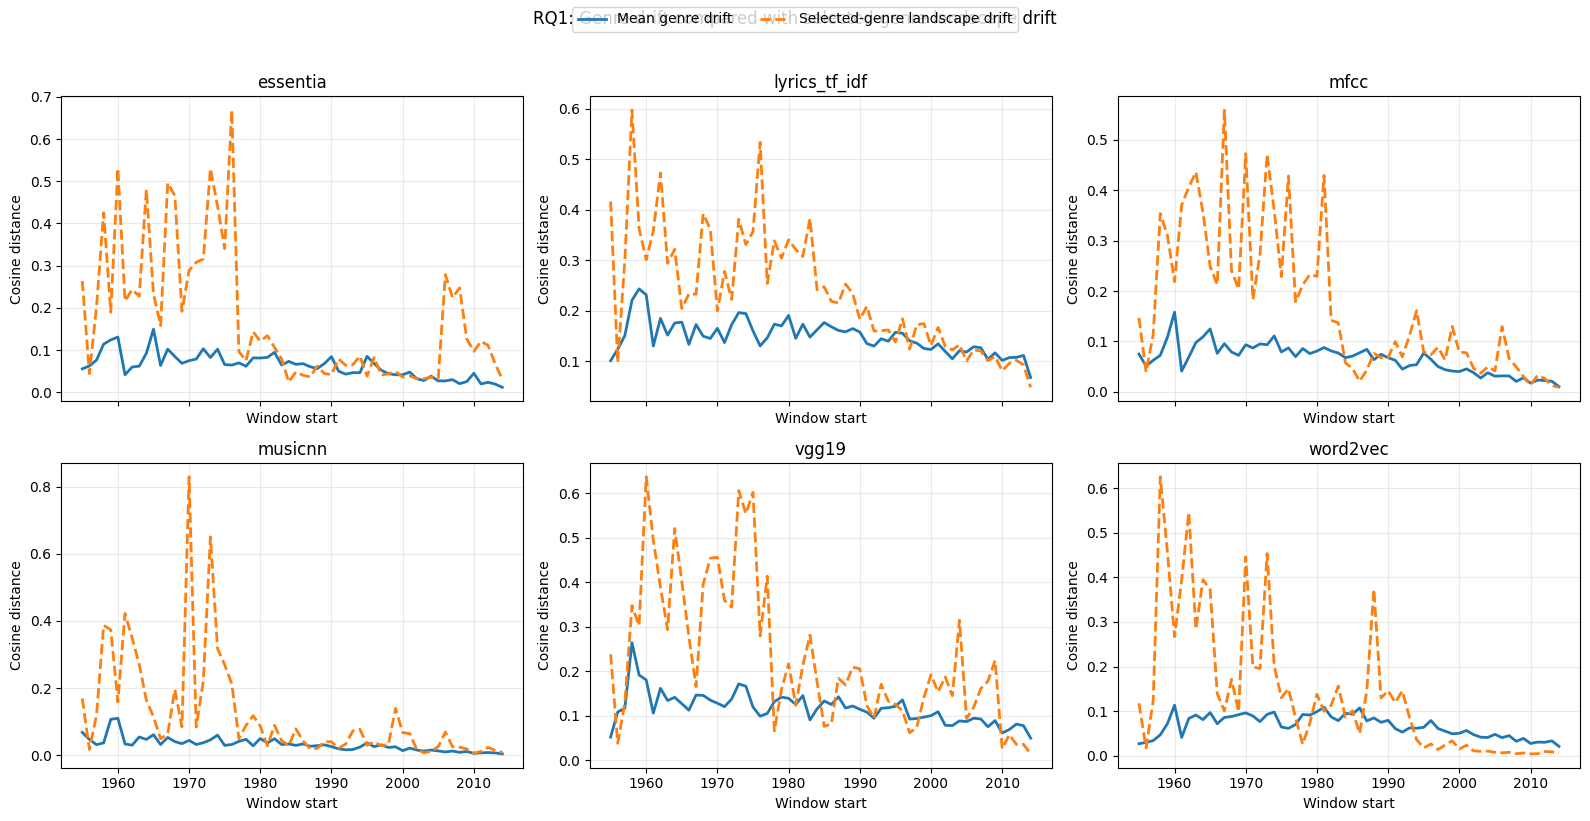

In [35]:
from scipy.spatial.distance import cosine
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metadata_columns = {
    "modality",
    "genre",
    "window_start",
    "window_end",
    "window_label",
    "n_tracks",
    "mean_genre_score",
    "median_genre_score",
}

# Calculate per-genre drift before forming the temporal mean.
genre_drift_by_window = (
    drift_wpz_neighbors
    .groupby(["modality", "window_start", "genre"], as_index=False)
    .agg(genre_mean_cosine_distance=("cosine_distance", "mean"))
)

genre_time = (
    genre_drift_by_window
    .groupby(["modality", "window_start"], as_index=False)
    .agg(
        mean_genre_cosine_distance=("genre_mean_cosine_distance", "mean"),
        n_genres=("genre", "nunique"),
    )
)

# Recalculate selected-genre landscape drift from centroids_wpz
landscape_rows = []

for modality in sorted(centroids_wpz["modality"].unique()):
    modality_centroids = centroids_wpz[
        centroids_wpz["modality"] == modality
    ].copy()

    feature_columns = [
        column for column in modality_centroids.columns
        if column not in metadata_columns
        and pd.api.types.is_numeric_dtype(modality_centroids[column])
        and modality_centroids[column].notna().any()
    ]

    modality_windows = sorted(
        modality_centroids["window_start"].dropna().unique()
    )

    for window_start, next_window_start in zip(
        modality_windows[:-1],
        modality_windows[1:],
    ):
        # Keep only direct sliding-window neighbors, e.g. 1955 -> 1956
        if next_window_start != window_start + 1:
            continue

        window_t = modality_centroids[
            modality_centroids["window_start"] == window_start
        ].copy()

        window_t1 = modality_centroids[
            modality_centroids["window_start"] == next_window_start
        ].copy()

        if window_t.empty or window_t1.empty:
            continue

        window_t = window_t.dropna(subset=feature_columns + ["n_tracks"])
        window_t1 = window_t1.dropna(subset=feature_columns + ["n_tracks"])

        if window_t.empty or window_t1.empty:
            continue

        landscape_t = np.average(
            window_t[feature_columns].to_numpy(dtype=float),
            axis=0,
            weights=window_t["n_tracks"].to_numpy(dtype=float),
        )

        landscape_t1 = np.average(
            window_t1[feature_columns].to_numpy(dtype=float),
            axis=0,
            weights=window_t1["n_tracks"].to_numpy(dtype=float),
        )

        if not np.isfinite(landscape_t).all():
            continue

        if not np.isfinite(landscape_t1).all():
            continue

        if np.all(landscape_t == 0) or np.all(landscape_t1 == 0):
            continue

        landscape_rows.append({
            "modality": modality,
            "window_start": window_start,
            "next_window_start": next_window_start,
            "landscape_cosine_distance": cosine(
                landscape_t,
                landscape_t1,
            ),
        })

landscape_drift_weighted = pd.DataFrame(landscape_rows)

baseline_comparison = genre_time.merge(
    landscape_drift_weighted[
        ["modality", "window_start", "landscape_cosine_distance"]
    ],
    on=["modality", "window_start"],
    how="left",
)

display(baseline_comparison.head())

modalities_for_plot = sorted(
    baseline_comparison["modality"].unique()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, modality in zip(axes, modalities_for_plot):
    data = baseline_comparison[
        baseline_comparison["modality"] == modality
    ].sort_values("window_start")

    ax.plot(
        data["window_start"],
        data["mean_genre_cosine_distance"],
        label="Mean genre drift",
        linewidth=2,
    )

    ax.plot(
        data["window_start"],
        data["landscape_cosine_distance"],
        label="Selected-genre landscape drift",
        linewidth=2,
        linestyle="--",
    )

    ax.set_title(modality)
    ax.set_xlabel("Window start")
    ax.set_ylabel("Cosine distance")
    ax.grid(alpha=0.25)

for ax in axes[len(modalities_for_plot):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
)

fig.suptitle(
    "RQ1: Genre drift compared with selected-genre landscape drift",
    y=1.02,
)

plt.tight_layout()

output_path = (
    PLOTS_DIR
    / "rq1_genre_drift_vs_weighted_landscape_baseline.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

# non overlapping for comparison:

essentia feature columns: 1034
lyrics_tf_idf feature columns: 1000
mfcc feature columns: 104
musicnn feature columns: 50
vgg19 feature columns: 8192
word2vec feature columns: 300


,modality,window_start,mean_genre_cosine_distance,n_genres,next_window_start,landscape_cosine_distance
0,essentia,1955,0.508071,6,1960,0.745187
1,essentia,1960,0.437547,11,1965,1.079525
2,essentia,1965,0.467944,18,1970,1.257190
3,essentia,1970,0.461804,24,1975,0.652603
4,essentia,1975,0.438887,27,1980,0.910608


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_non_overlapping_genre_drift_vs_landscape_baseline_corrected.png


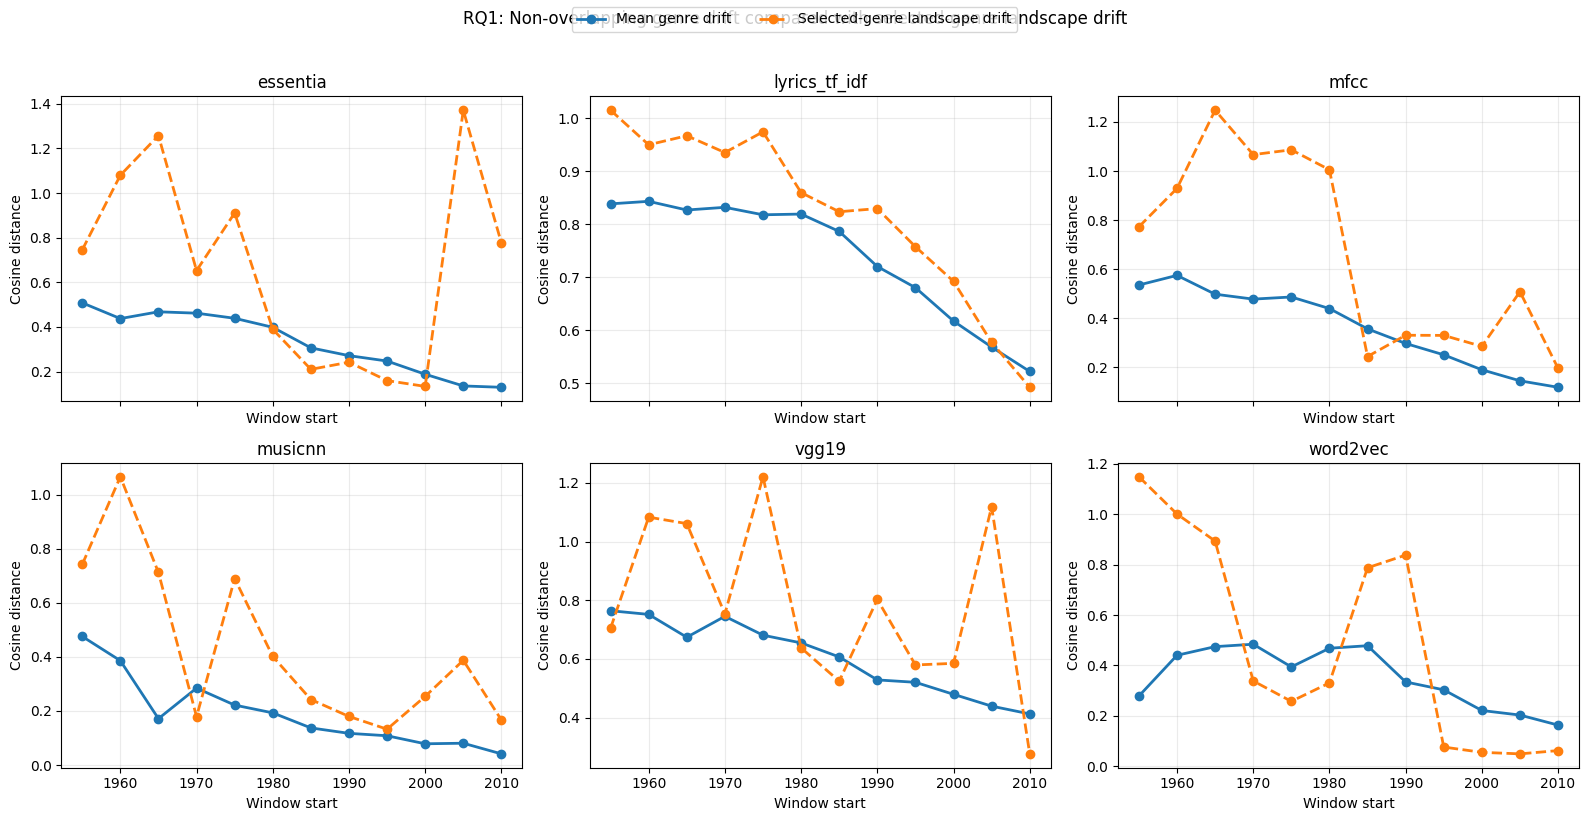

In [15]:
from scipy.spatial.distance import cosine
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

analysis_min_year = 1955
analysis_max_year = 2019
window_size = 5

non_overlapping_starts = list(
    range(
        analysis_min_year,
        analysis_max_year - window_size + 2,
        window_size,
    )
)

metadata_columns = {
    "modality",
    "genre",
    "window_start",
    "window_end",
    "window_label",
    "n_tracks",
    "mean_genre_score",
    "median_genre_score",
}

non_overlapping_rows = []
non_overlapping_landscape_rows = []

for modality in sorted(centroids_wpz["modality"].unique()):
    modality_centroids = centroids_wpz[
        centroids_wpz["modality"] == modality
    ].copy()

    feature_columns = [
        column for column in modality_centroids.columns
        if column not in metadata_columns
        and pd.api.types.is_numeric_dtype(modality_centroids[column])
        and modality_centroids[column].notna().any()
    ]

    print(modality, "feature columns:", len(feature_columns))

    # Genre-level drift
    for genre in sorted(modality_centroids["genre"].unique()):
        genre_centroids = (
            modality_centroids[
                modality_centroids["genre"] == genre
            ]
            .drop_duplicates(subset=["window_start"])
            .set_index("window_start")
            .sort_index()
        )

        for window_start in non_overlapping_starts:
            next_window_start = window_start + window_size

            if window_start not in genre_centroids.index:
                continue
            if next_window_start not in genre_centroids.index:
                continue

            centroid_t = genre_centroids.loc[
                window_start, feature_columns
            ].to_numpy(dtype=float)

            centroid_t1 = genre_centroids.loc[
                next_window_start, feature_columns
            ].to_numpy(dtype=float)

            if not np.isfinite(centroid_t).all():
                continue
            if not np.isfinite(centroid_t1).all():
                continue
            if np.all(centroid_t == 0) or np.all(centroid_t1 == 0):
                continue

            non_overlapping_rows.append({
                "modality": modality,
                "genre": genre,
                "window_start": window_start,
                "next_window_start": next_window_start,
                "cosine_distance": cosine(centroid_t, centroid_t1),
            })

    # Correct non-overlapping landscape baseline
    for window_start in non_overlapping_starts:
        next_window_start = window_start + window_size

        window_t = modality_centroids[
            modality_centroids["window_start"] == window_start
        ].copy()

        window_t1 = modality_centroids[
            modality_centroids["window_start"] == next_window_start
        ].copy()

        if window_t.empty or window_t1.empty:
            continue

        window_t = window_t.dropna(subset=feature_columns + ["n_tracks"])
        window_t1 = window_t1.dropna(subset=feature_columns + ["n_tracks"])

        if window_t.empty or window_t1.empty:
            continue

        landscape_t = np.average(
            window_t[feature_columns].to_numpy(dtype=float),
            axis=0,
            weights=window_t["n_tracks"].to_numpy(dtype=float),
        )

        landscape_t1 = np.average(
            window_t1[feature_columns].to_numpy(dtype=float),
            axis=0,
            weights=window_t1["n_tracks"].to_numpy(dtype=float),
        )

        if not np.isfinite(landscape_t).all():
            continue
        if not np.isfinite(landscape_t1).all():
            continue
        if np.all(landscape_t == 0) or np.all(landscape_t1 == 0):
            continue

        non_overlapping_landscape_rows.append({
            "modality": modality,
            "window_start": window_start,
            "next_window_start": next_window_start,
            "landscape_cosine_distance": cosine(landscape_t, landscape_t1),
        })

non_overlapping_drift = pd.DataFrame(non_overlapping_rows)
non_overlapping_landscape_drift = pd.DataFrame(non_overlapping_landscape_rows)

non_overlapping_time = (
    non_overlapping_drift
    .groupby(["modality", "window_start"])
    .agg(
        mean_genre_cosine_distance=("cosine_distance", "mean"),
        n_genres=("genre", "nunique"),
    )
    .reset_index()
)

baseline_comparison_non_overlapping = non_overlapping_time.merge(
    non_overlapping_landscape_drift,
    on=["modality", "window_start"],
    how="left",
)

display(baseline_comparison_non_overlapping.head())

modalities_for_plot = sorted(
    baseline_comparison_non_overlapping["modality"].unique()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, modality in zip(axes, modalities_for_plot):
    data = baseline_comparison_non_overlapping[
        baseline_comparison_non_overlapping["modality"] == modality
    ].sort_values("window_start")

    ax.plot(
        data["window_start"],
        data["mean_genre_cosine_distance"],
        marker="o",
        linewidth=2,
        label="Mean genre drift",
    )

    ax.plot(
        data["window_start"],
        data["landscape_cosine_distance"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Selected-genre landscape drift",
    )

    ax.set_title(modality)
    ax.set_xlabel("Window start")
    ax.set_ylabel("Cosine distance")
    ax.grid(alpha=0.25)

for ax in axes[len(modalities_for_plot):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle(
    "RQ1: Non-overlapping genre drift compared with selected-genre landscape drift",
    y=1.02,
)

plt.tight_layout()

output_path = (
    PLOTS_DIR
    / "rq1_non_overlapping_genre_drift_vs_landscape_baseline_corrected.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Summarize Landscape Baseline Difference

mean_landscape_cosine_distance:
- all tracks centroid 1980-1984 vs all tracks centroid 1981-1985
---
mean_genre_cosine_distance:
- rock centroid 1980-1984 vs rock centroid 1981-1985
- pop centroid 1980-1984 vs pop centroid 1981-1985
- average all of them

In [16]:
baseline_summary = (
    baseline_comparison
    .groupby("modality")
    .agg(
        mean_genre_cosine_distance=("mean_genre_cosine_distance", "mean"),
        mean_landscape_cosine_distance=("landscape_cosine_distance", "mean"),
    )
    .reset_index()
)

baseline_summary["genre_minus_landscape"] = (
    baseline_summary["mean_genre_cosine_distance"]
    - baseline_summary["mean_landscape_cosine_distance"]
)

baseline_summary.sort_values("genre_minus_landscape", ascending=False)

,modality,mean_genre_cosine_distance,mean_landscape_cosine_distance,genre_minus_landscape
5,word2vec,0.066769,0.137442,-0.070673
3,musicnn,0.032877,0.119816,-0.086939
1,lyrics_tf_idf,0.148275,0.237109,-0.088834
2,mfcc,0.065403,0.169250,-0.103847
0,essentia,0.063016,0.172871,-0.109855
4,vgg19,0.117362,0.230707,-0.113345


## Identify Highest-Drift Genres Per Modality

In [17]:
top_n = 10

top_drifting_genres = (
    genre_drift_summary
    .sort_values(
        ["modality", "mean_cosine_distance"],
        ascending=[True, False],
    )
    .groupby("modality")
    .head(top_n)
    .reset_index(drop=True)
)

top_drifting_genres

,modality,genre,n_transitions,mean_cosine_distance,median_cosine_distance,mean_euclidean_distance,median_euclidean_distance,median_tracks_t,median_tracks_t1
0,essentia,brazilian rock,33,0.115420,0.099050,2.632643,2.418131,47.0,48.0
1,essentia,glam rock,34,0.112152,0.099426,2.892782,2.879982,28.5,28.5
2,essentia,experimental,51,0.110943,0.086651,3.163517,2.718116,37.0,38.0
3,essentia,rock,60,0.110260,0.062423,1.899933,1.454777,149.0,175.5
4,essentia,progressive rock,52,0.110050,0.086498,2.204718,1.914957,145.0,158.0
5,essentia,psychedelic rock,45,0.103921,0.058718,2.666811,2.180728,59.0,59.0
6,essentia,soft rock,48,0.102533,0.077291,2.911739,2.734413,42.0,42.5
7,essentia,post-punk,42,0.085763,0.063197,1.974923,1.682175,154.0,157.5
8,essentia,pop rock,30,0.079275,0.037550,2.296286,1.912350,130.0,184.5
9,essentia,new wave,42,0.075743,0.055173,1.616960,1.575688,133.0,136.5


## Plot Highest-Drift Genres For One Modality

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_top_drifting_genres_word2vec.png


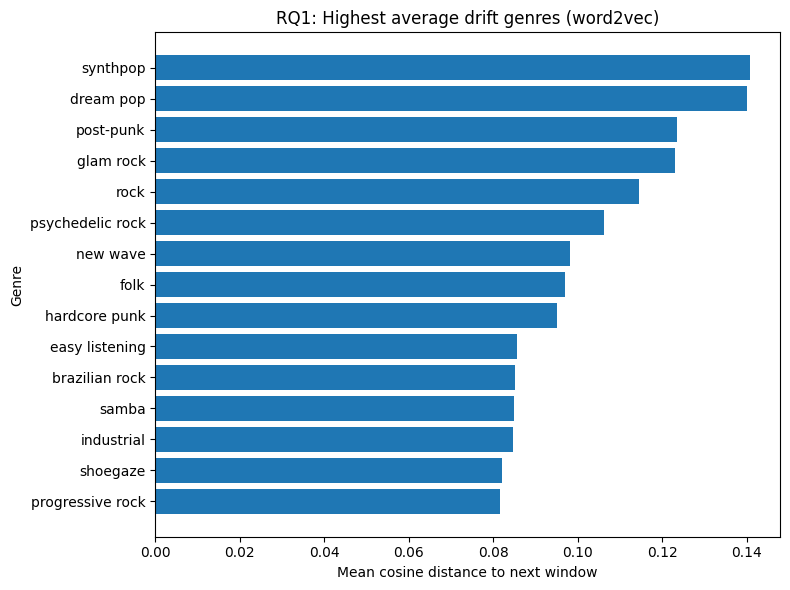

In [18]:
selected_modality = "word2vec"
top_n = 15

plot_data = (
    genre_drift_summary[genre_drift_summary["modality"] == selected_modality]
    .sort_values("mean_cosine_distance", ascending=True)
    .tail(top_n)
)

plt.figure(figsize=(8, 6))
plt.barh(plot_data["genre"], plot_data["mean_cosine_distance"])
plt.xlabel("Mean cosine distance to next window")
plt.ylabel("Genre")
plt.title(f"RQ1: Highest average drift genres ({selected_modality})")
plt.tight_layout()

output_path = PLOTS_DIR / f"rq1_top_drifting_genres_{selected_modality}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Check Whether Drift Is Driven By Few Extreme Genres

In [19]:
genre_variation = (
    genre_drift_summary
    .groupby("modality")
    .agg(
        mean_of_genre_means=("mean_cosine_distance", "mean"),
        median_of_genre_means=("mean_cosine_distance", "median"),
        p90_of_genre_means=("mean_cosine_distance", lambda values: values.quantile(0.90)),
        max_of_genre_means=("mean_cosine_distance", "max"),
    )
    .reset_index()
)

genre_variation["max_to_median_ratio"] = (
    genre_variation["max_of_genre_means"]
    / genre_variation["median_of_genre_means"]
)

genre_variation.sort_values("mean_of_genre_means", ascending=False)

,modality,mean_of_genre_means,median_of_genre_means,p90_of_genre_means,max_of_genre_means,max_to_median_ratio
1,lyrics_tf_idf,0.138956,0.144210,0.182344,0.190630,1.321893
4,vgg19,0.106170,0.110277,0.143544,0.185321,1.680511
5,word2vec,0.063515,0.062850,0.107140,0.140883,2.241577
2,mfcc,0.055637,0.047847,0.107622,0.130452,2.726450
0,essentia,0.054254,0.046670,0.104534,0.115420,2.473104
3,musicnn,0.025686,0.020989,0.056547,0.087152,4.152280


## Compare Raw And Within-Period Normalized Drift

In [20]:
raw_vs_wpz_summary.sort_values("wpz_mean_cosine_distance", ascending=False)

,modality,wpz_mean_cosine_distance,wpz_median_cosine_distance,wpz_mean_euclidean_distance,wpz_median_euclidean_distance,raw_mean_cosine_distance,raw_median_cosine_distance,raw_mean_euclidean_distance,raw_median_euclidean_distance
1,lyrics_tf_idf,0.138956,0.144210,2.337153,2.242259,0.041745,0.029942,0.067959,0.060119
4,vgg19,0.106170,0.110277,8.123186,7.972392,0.004640,0.002567,7.891632,6.967401
5,word2vec,0.063515,0.062850,1.305929,1.243031,0.001605,0.000902,0.017987,0.015515
2,mfcc,0.055637,0.047847,0.773923,0.776803,0.001099,0.000606,17.155774,14.223112
0,essentia,0.054254,0.046670,2.338798,2.344472,0.001970,0.000035,145670.192883,80367.377169
3,musicnn,0.025686,0.020989,0.536921,0.496839,0.002663,0.001122,0.037926,0.031194


## Notes And Limitations

- The main comparison uses within-period z-normalized centroids, so the result describes relative genre movement within the feature distribution of the same period.
- Cosine distance captures changes in feature profile direction. Euclidean distance also captures displacement magnitude and is more sensitive to feature dimensionality.
- The analysis uses neighboring sliding windows with one-year hops. For statistical testing, non-overlapping windows or temporal-dependence-aware methods should be used.
- VGG19 may have slightly lower coverage than the other modalities because visual features are not available for all tracks.
- The selected-genre landscape baseline is based on the OR-Tools selected genre set, not the complete track-level dataset.

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_top_bottom_5_drifting_genres_lyrics_tf_idf.png


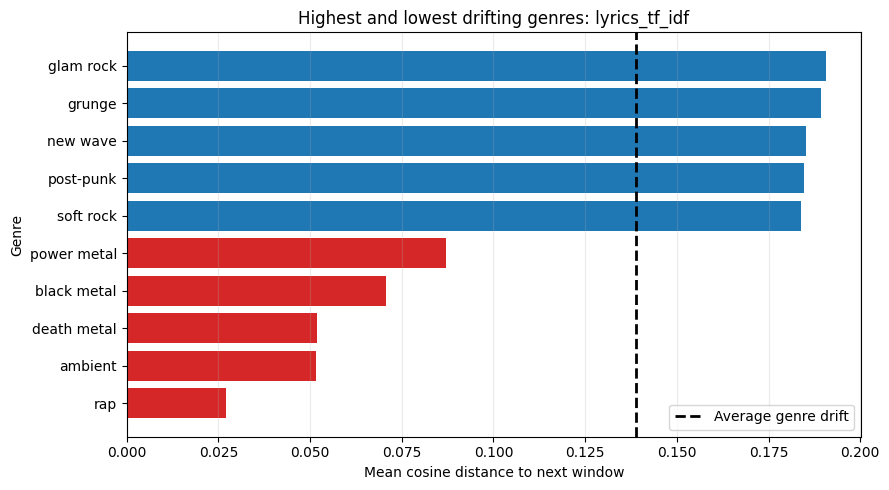

In [21]:
selected_modality = "lyrics_tf_idf"
n_extreme_genres = 5

modality_genre_summary = genre_drift_summary[
    genre_drift_summary["modality"] == selected_modality
].copy()

highest_drift_genres = (
    modality_genre_summary
    .sort_values("mean_cosine_distance", ascending=False)
    .head(n_extreme_genres)
)

lowest_drift_genres = (
    modality_genre_summary
    .sort_values("mean_cosine_distance", ascending=True)
    .head(n_extreme_genres)
)

plot_data = (
    pd.concat([lowest_drift_genres, highest_drift_genres], ignore_index=True)
    .sort_values("mean_cosine_distance", ascending=True)
)

average_genre_drift = modality_genre_summary["mean_cosine_distance"].mean()

colors = [
    "tab:blue" if value >= average_genre_drift else "tab:red"
    for value in plot_data["mean_cosine_distance"]
]

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["genre"],
    plot_data["mean_cosine_distance"],
    color=colors,
)

plt.axvline(
    average_genre_drift,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Average genre drift",
)

plt.xlabel("Mean cosine distance to next window")
plt.ylabel("Genre")
plt.title(
    f"Highest and lowest drifting genres: {selected_modality}"
)

plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

output_path = (
    PLOTS_DIR
    / f"rq1_top_bottom_{n_extreme_genres}_drifting_genres_{selected_modality}.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()